In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Singular Value Decomposition


Singular value decomposition (SVD) is a factorization of a matrix into three matrices. It is used in many applications such as data compression, denoising, and solving linear systems of equations. In scientific machine learning, it is also used in principal component analysis (PCA) and the numerical construction of Karhunen--Loève expansions.

A broader treatment appears in {cite:t}`brunton2019datadriven`.

Let $\mathbf{X}$ be an $n \times m$ matrix.
Think of $\mathbf{X}$ as the matrix you obtain when doing $n$ experiments and measuring $m$ different things.
The SVD of $\mathbf{X}$ is given by

$$
\mathbf{X} = \mathbf{U} \mathbf{\Sigma} \mathbf{V}^T
$$

where $\mathbf{U}$ is an $n \times n$ orthogonal matrix, $\mathbf{\Sigma}$ is an $n \times m$ matrix with non-negative real numbers on the diagonal and zeros elsewhere, and $\mathbf{V}$ is an $m \times m$ orthogonal matrix.

The columns of $\mathbf{U}$ are called the left singular vectors of $\mathbf{X}$, the columns of $\mathbf{V}$ are called the right singular vectors of $\mathbf{X}$, and the diagonal elements of $\mathbf{\Sigma}$ are called the singular values of $\mathbf{X}$.

## Economy-size SVD
Assume that $n \geq m$.
Then, $\mathbf{\Sigma}$ has the form:

$$
\mathbf{\Sigma} = \begin{bmatrix}
\hat{\mathbf{\Sigma}} \\
\mathbf{0}
\end{bmatrix},
$$

where $\hat{\mathbf{\Sigma}}$ is an $m \times m$ diagonal matrix with non-negative real numbers on the diagonal and zeros elsewhere, and $\mathbf{0}$ is an $(n-m) \times m$ matrix with zeros.
Now, only the first $m$ columns of $\mathbf{U}$ are needed to represent $\mathbf{X}$.
We write the **economy-size** SVD as:

$$
\mathbf{X} = \mathbf{U}_m \hat{\mathbf{\Sigma}} \mathbf{V}^T,
$$

where $\mathbf{U}_m$ is an $n \times m$ matrix with the first $m$ columns of $\mathbf{U}$.

## Truncated SVD

The truncated SVD is a low-rank approximation of $\mathbf{X}$.
It is given by:

$$
\mathbf{X} \approx \mathbf{U}_k \hat{\mathbf{\Sigma}}_k \mathbf{V}_k^T,
$$

where $\mathbf{U}_k$ is an $n \times k$ matrix with the first $k$ columns of $\mathbf{U}$, $\hat{\mathbf{\Sigma}}_k$ is a $k \times k$ diagonal matrix with the first $k$ singular values of $\mathbf{\Sigma}$, and $\mathbf{V}_k$ is an $m \times k$ matrix with the first $k$ columns of $\mathbf{V}$.

We can also write:

$$
\mathbf{X} \approx \mathbf{X}_k = \sum_{i=1}^k \sigma_i \mathbf{u}_i \mathbf{v}_i^T,
$$

where $\sigma_i$ is the $i$-th singular value, and $\mathbf{u}_i$ and $\mathbf{v}_i$ are the $i$-th columns of $\mathbf{U}$ and $\mathbf{V}$, respectively.

One can show that the matrix $\mathbf{X}_k$ is the best rank-$k$ approximation of $\mathbf{X}$ in the Frobenius norm. The Frobenius norm is the square root of the sum of the squared matrix entries, $\|\mathbf{A}\|_F=\sqrt{\sum_{i,j}A_{ij}^2}$, so it measures the total entrywise approximation error.



## Demonstration - SVD for image compression

We compress the grayscale image below using the truncated SVD.

In [3]:
# If you are working on Google Colab run this to download the image:
!curl -O "https://raw.githubusercontent.com/PredictiveScienceLab/advanced-scientific-machine-learning/main/book/hup/funcin/neom-DMGDdksVoWI-unsplash.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

100  751k  100  751k    0     0  3997k      0 --:--:-- --:--:-- --:--:-- 4019k


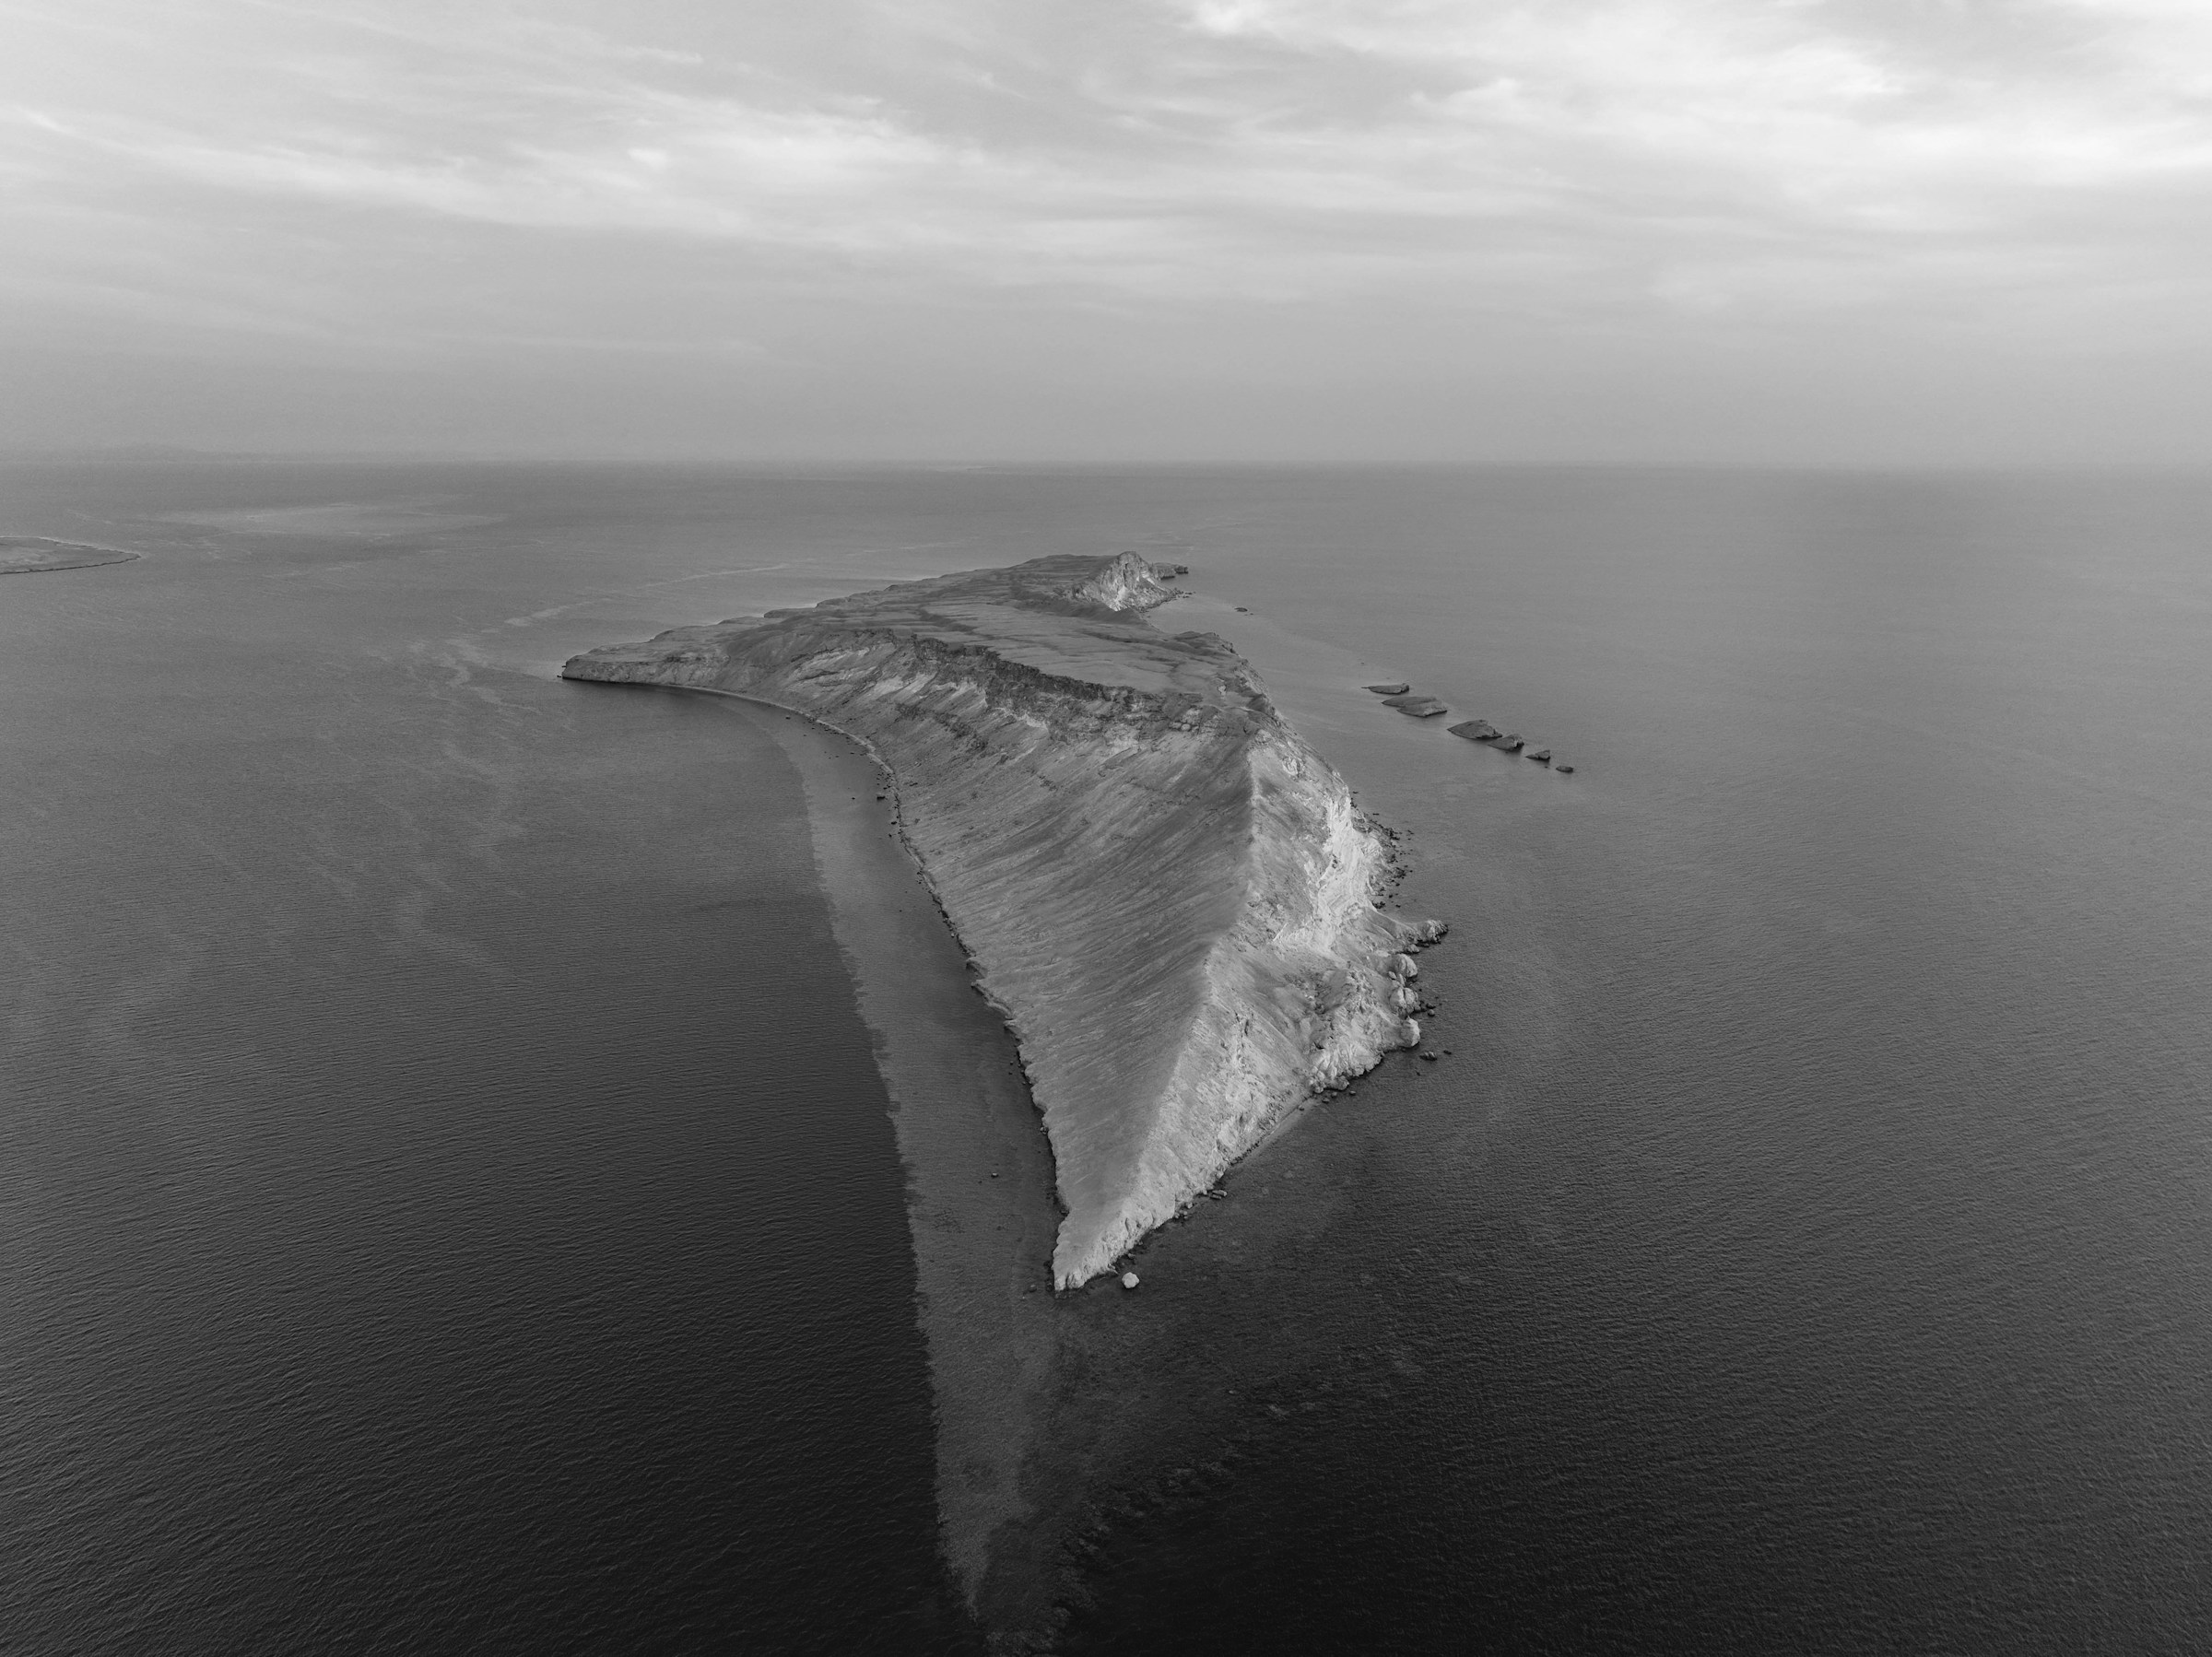

In [4]:
from PIL import Image
with open("neom-DMGDdksVoWI-unsplash.jpg", "rb") as f:
    img = Image.open(f)
    img = img.convert("L")  # convert to grayscale
img

Extract the matrix that represents the image:

In [5]:
import numpy as np
X = np.array(img)
X.shape

(1798, 2400)

Do SVD of the matrix:

In [6]:
U, s, Vt = np.linalg.svd(X, full_matrices=False)

Let's look at the singular values as a function of the index:

array([<Axes: xlabel='Singular value index', ylabel='Singular value'>],
      dtype=object)

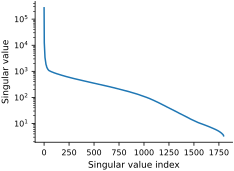

In [7]:
fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(s)
ax.set(yscale='log', xlabel="Singular value index", ylabel="Singular value")
finalize_axes(keep_box=False)

Typically, we pick the number of singular values such that the sum of the squares of the singular values is a certain percentage of the sum of the squares of all the singular values.
For example, we can pick $k$ so that:

$$
\frac{\sum_{i=1}^k \sigma_i^2}{\sum_{i=1}^{\min(n,m)} \sigma_i^2} \geq 0.998.
$$

To facilitate our choice we can do the following plot:

array([<Axes: xlabel='Singular value index', ylabel='Cumulative fraction of total variance'>],
      dtype=object)

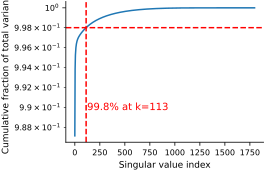

In [8]:
cum_var = np.cumsum(s**2)/np.sum(s**2)
best_k = np.argmax(cum_var > 0.998)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_standard"])
ax.plot(cum_var)
ax.axhline(0.998, color='red', linestyle='--')
ax.axvline(best_k, color='red', linestyle='--')
ax.text(best_k + 10, 0.99, f'99.8% at k={best_k}', verticalalignment='center', color='red')
ax.set(yscale='log', xlabel="Singular value index", ylabel="Cumulative fraction of total variance")
finalize_axes(keep_box=False)

Let's plot the compressed images for some choices of $k$:

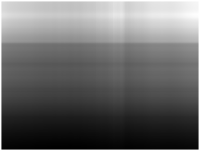

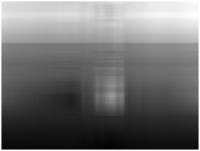

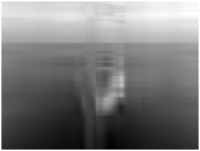

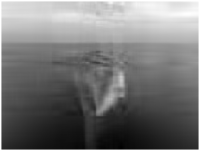

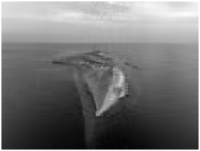

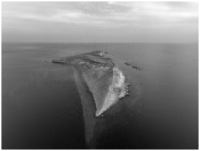

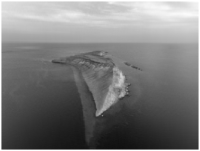

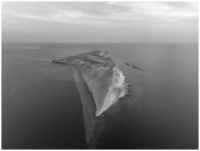

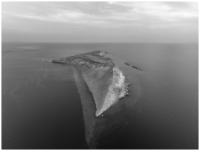

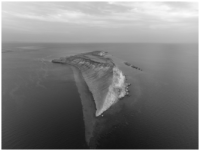

In [9]:
ks = [1, 2, 4, 8, 16, 32, 64, 128, 256, 682]

for k in ks:
    X_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"])
    ax.imshow(X_k, cmap='gray')
    ax.axis('off')